In [1]:
from scipy.io import readsav
import numpy as np

import matplotlib.pyplot as plt

In [2]:

data_dict = readsav(r'C:\Users\menes\Downloads\phase_matrix.sav')
print(data_dict.keys())

KL = data_dict['klmatrix']
xx = data_dict['xx']
yy = data_dict['yy']

Npix = data_dict['dpix']

m2c_full = data_dict['klm2c']
m2c = m2c_full[:,:KL.shape[1]]

idx = data_dict['idx_mask']

dict_keys(['klmatrix', 'dpix', 'idx_mask', 'xx', 'yy', 'klm2c', 'mm_info'])


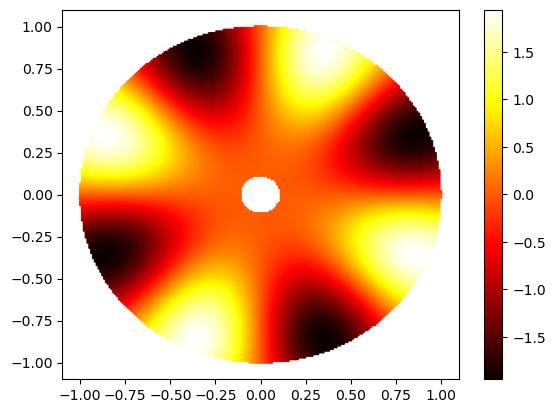

In [3]:
plt.figure()
plt.scatter(xx,yy,s=1,c=KL[:,10],cmap='hot')
plt.colorbar()

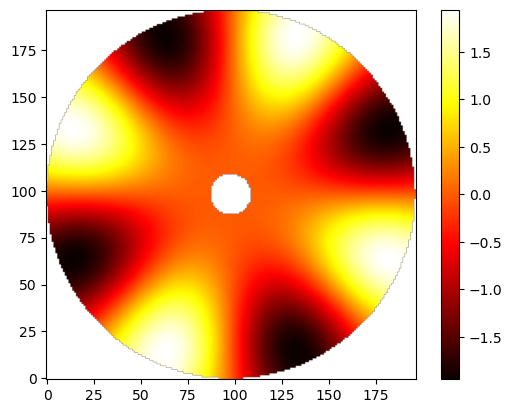

In [ ]:
img = np.ones([Npix,Npix],dtype=bool).flatten()
img[idx] = False
mask = img.reshape([Npix,Npix])

img = np.zeros([Npix,Npix]).flatten()
img[idx] = KL[:,10]

plt.figure()
plt.imshow(np.ma.masked_array(img.reshape([Npix,Npix]),mask=mask),origin='lower',cmap='hot')
plt.colorbar()

<Figure size 640x480 with 0 Axes>

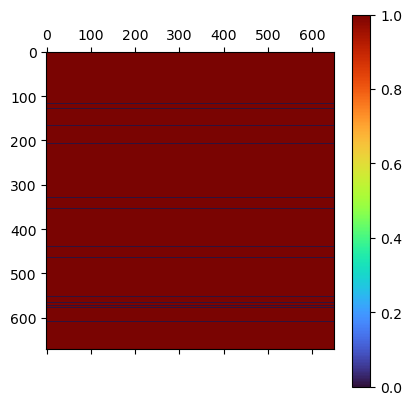

In [5]:
plt.figure()
plt.matshow(abs(m2c)>0,cmap='turbo')
plt.colorbar()

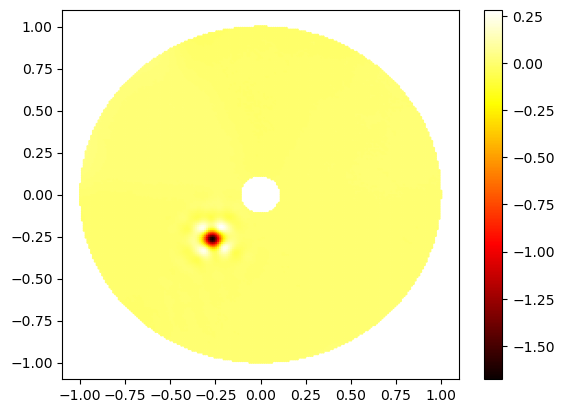

In [6]:
IF = KL @ np.linalg.pinv(m2c)
plt.figure()
plt.scatter(xx,yy,s=1,c=IF[:,200],cmap='hot')
plt.colorbar()